#Name: OBAJE PAUL

In [2]:
# Assignment 9: Unsupervised Learning
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
# Load the Wine dataset

wine = load_wine()

# Create a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
# Display basic information about the dataset

print("First five rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

First five rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
# Check for missing values

print("Missing values:")
print(df.isnull().sum())

# Check for duplicate rows

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Number of duplicate rows:
0


In [6]:
# Remove duplicate rows if any exist

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (178, 13)


In [7]:
# Select all numerical features for clustering

X = df.copy()

print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])

Number of features: 13
Number of observations: 178


In [8]:
# Standardize the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized successfully.")
print("Scaled data shape:", X_scaled.shape)

Features standardized successfully.
Scaled data shape: (178, 13)


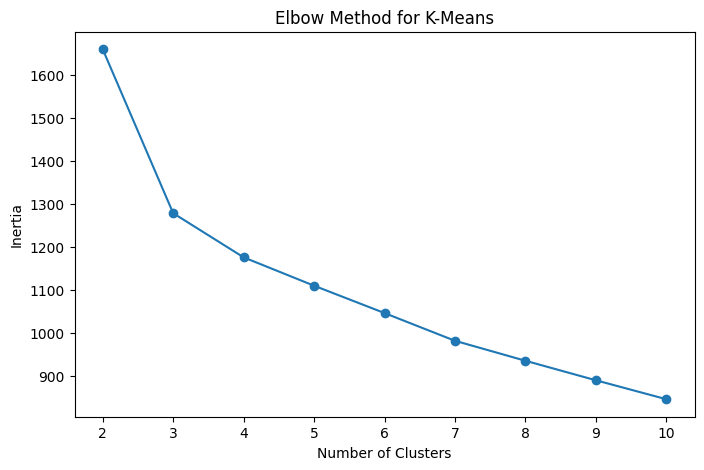

In [9]:
# Use the Elbow Method to find a suitable number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range(2, 11))
plt.show()

,Number of Clusters,Silhouette Score
0,2,0.259317
1,3,0.284859
2,4,0.260170
3,5,0.201619
4,6,0.237167
5,7,0.203628
6,8,0.157014
7,9,0.149882
8,10,0.143638


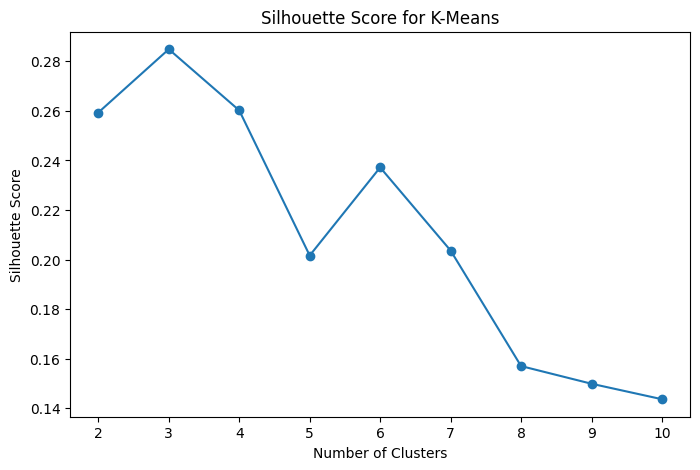

In [10]:
# Calculate silhouette scores for different numbers of clusters

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "Number of Clusters": range(2, 11),
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(range(2, 11))
plt.show()

In [11]:
# Train the K-Means model using 3 clusters

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the DataFrame

df["KMeans_Cluster"] = kmeans_labels

print("K-Means clustering completed.")
print("\nCluster counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())

K-Means clustering completed.

Cluster counts:
KMeans_Cluster
0    65
1    51
2    62
Name: count, dtype: int64


In [12]:
# Calculate the silhouette score for K-Means

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))

K-Means Silhouette Score: 0.2849


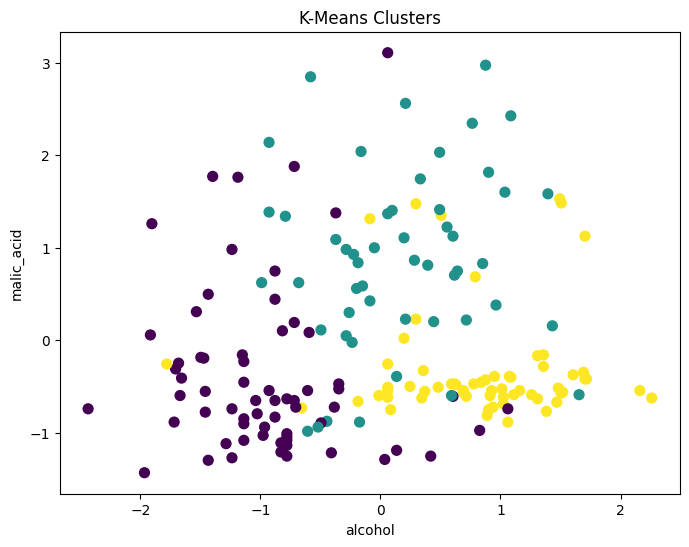

In [13]:
# Visualize K-Means clusters using two features

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=50
)

plt.xlabel(wine.feature_names[0])
plt.ylabel(wine.feature_names[1])
plt.title("K-Means Clusters")
plt.show()

In [14]:
# Apply Agglomerative (Hierarchical) Clustering

hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Add the cluster labels to the DataFrame

df["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical clustering completed.")
print("\nCluster counts:")
print(df["Hierarchical_Cluster"].value_counts().sort_index())

Hierarchical clustering completed.

Cluster counts:
Hierarchical_Cluster
0    58
1    56
2    64
Name: count, dtype: int64


In [15]:
# Calculate the silhouette score for Hierarchical Clustering

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

Hierarchical Clustering Silhouette Score: 0.2774


,Clustering Method,Silhouette Score
0,K-Means,0.284859
1,Hierarchical Clustering,0.277444


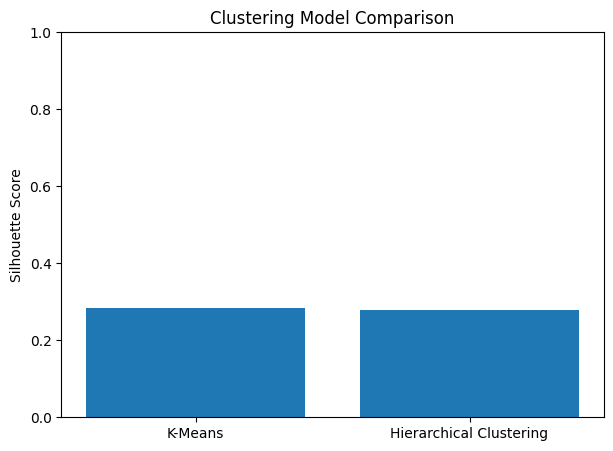

In [16]:
# Compare the silhouette scores of both clustering methods

comparison = pd.DataFrame({
    "Clustering Method": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

display(comparison)

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Clustering Method"],
    comparison["Silhouette Score"]
)

plt.ylabel("Silhouette Score")
plt.title("Clustering Model Comparison")
plt.ylim(0, 1)
plt.show()

In [17]:
# Apply PCA to reduce the 13 features to 2 principal components

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print("Original number of features:", X_scaled.shape[1])
print("Reduced number of features:", X_pca.shape[1])

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained by the two components:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

PCA completed.
Original number of features: 13
Reduced number of features: 2

Explained variance ratio:
[0.36198848 0.1920749 ]

Total variance explained by the two components: 0.5541


In [18]:
# Create a DataFrame containing the PCA results

pca_df = pd.DataFrame(
    X_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Cluster"] = kmeans_labels

display(pca_df.head())

,Principal Component 1,Principal Component 2,Cluster
0,3.316751,1.443463,2
1,2.209465,-0.333393,2
2,2.516740,1.031151,2
3,3.757066,2.756372,2
4,1.008908,0.869831,2


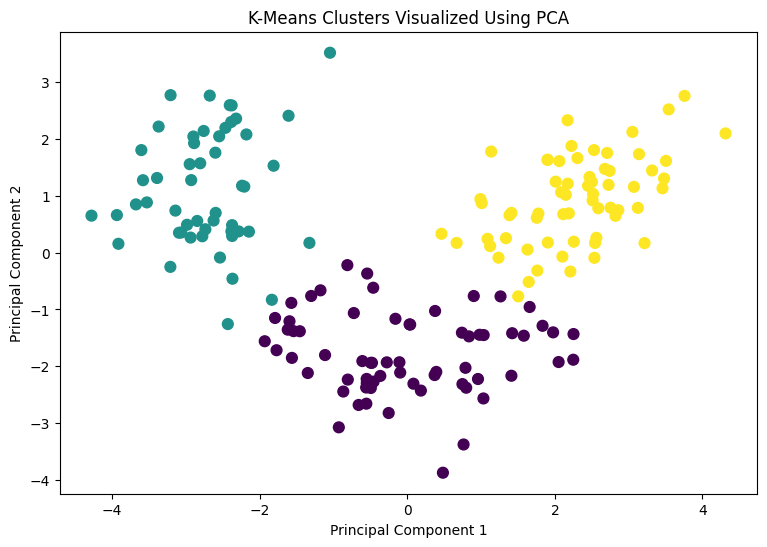

In [19]:
# Visualize the K-Means clusters after PCA dimensionality reduction

plt.figure(figsize=(9, 6))

plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")

plt.show()

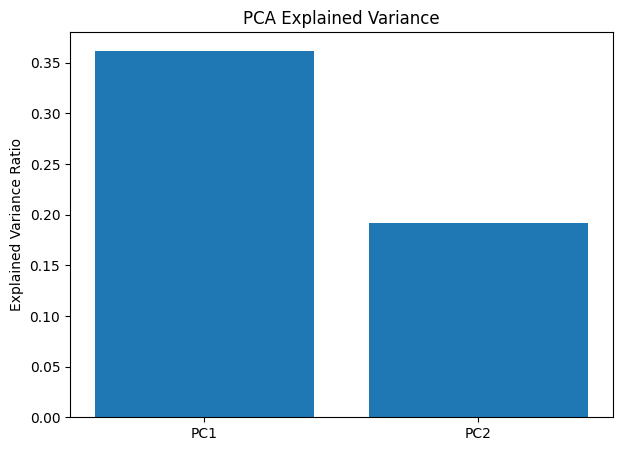

In [20]:
# Visualize the amount of variance explained by each principal component

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(7, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance
)

plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")

plt.show()

In [21]:
# Display the main results of the analysis

print("========== ASSIGNMENT 9 RESULTS ==========")

print("\nDataset:")
print("Wine dataset")
print("Observations:", X.shape[0])
print("Features:", X.shape[1])

print("\nK-Means:")
print("Number of clusters:", 3)
print("Silhouette Score:", round(kmeans_silhouette, 4))

print("\nHierarchical Clustering:")
print("Number of clusters:", 3)
print(
    "Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

print("\nPCA:")
print(
    "Variance explained by PC1:",
    round(explained_variance[0] * 100, 2),
    "%"
)

print(
    "Variance explained by PC2:",
    round(explained_variance[1] * 100, 2),
    "%"
)

print(
    "Total variance explained:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

========== ASSIGNMENT 9 RESULTS ==========

Dataset:
Wine dataset
Observations: 178
Features: 13

K-Means:
Number of clusters: 3
Silhouette Score: 0.2849

Hierarchical Clustering:
Number of clusters: 3
Silhouette Score: 0.2774

PCA:
Variance explained by PC1: 36.2 %
Variance explained by PC2: 19.21 %
Total variance explained: 55.41 %


In [22]:
# Determine which clustering method performed better

if kmeans_silhouette > hierarchical_silhouette:
    best_model = "K-Means"
    best_score = kmeans_silhouette
else:
    best_model = "Hierarchical Clustering"
    best_score = hierarchical_silhouette

print("Best-performing clustering method:", best_model)
print("Silhouette Score:", round(best_score, 4))

Best-performing clustering method: K-Means
Silhouette Score: 0.2849


## Deployment and Monitoring Strategy

The best-performing clustering model could be deployed in a data analysis or customer segmentation system. New observations could be processed using the same feature scaling method used during training and then assigned to the appropriate cluster.

A production deployment may face challenges such as processing large amounts of data, prediction latency, changes in incoming data and maintaining consistent preprocessing. The scaling process and trained clustering model should therefore be saved and used consistently when new data is received.

The model should be monitored by checking cluster sizes, silhouette scores and changes in the distribution of incoming data. If the clusters become less meaningful or the data distribution changes significantly, the model can be retrained using newer data. Regular monitoring would help maintain the usefulness of the clustering system over time.

## Conclusion

This project applied unsupervised learning techniques to the Wine dataset. The data was cleaned, checked for duplicates and standardized before clustering. K-Means and Hierarchical Clustering were applied using three clusters, with the Elbow Method and Silhouette Score used to evaluate the clustering structure.

PCA was also applied to reduce the 13-dimensional dataset to two principal components, making it easier to visualize the cluster structure. The clustering models were compared using their Silhouette Scores, and the model with the higher score was selected as the better-performing method.

Overall, the analysis demonstrated how clustering can identify groups within data without using predefined target labels, while PCA can help visualize patterns in high-dimensional datasets.